
# 17. 장기 기억: 날마다 아는 게 쌓인다

지금까지 MK1은 세션이 끝나면 다 잊었다. 이제는 **세상이 "이게 맞았다"고 확인해 준 사실**을 세션을 넘어 기억한다. 확인되지 않은 자기 결론은 적지 않는다.

- 실제 기사 100세션을 하루 10세션씩 차례로 푼다.
- 쌓은 기억을 얼려서, **다른 종류의 문제**(기사로 여는 문: 열쇠 이름표 + 사슬 추론)에 중재자의 세 번째 통로로 넣는다.


In [1]:

import json
import numpy as np
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V
V.setup()
r = json.loads((S.RESULTS / "mk1-h_long_term_memory.json").read_text(encoding="utf-8"))
print(json.dumps(r["criteria"], ensure_ascii=False))


{"1a_memory_helps": true, "1b_grows_over_days": true, "2_carries_to_another_task": true, "3_no_harm_when_unknown": true, "4_no_wrong_memories": true}


## 1. 날마다 똑똑해진다

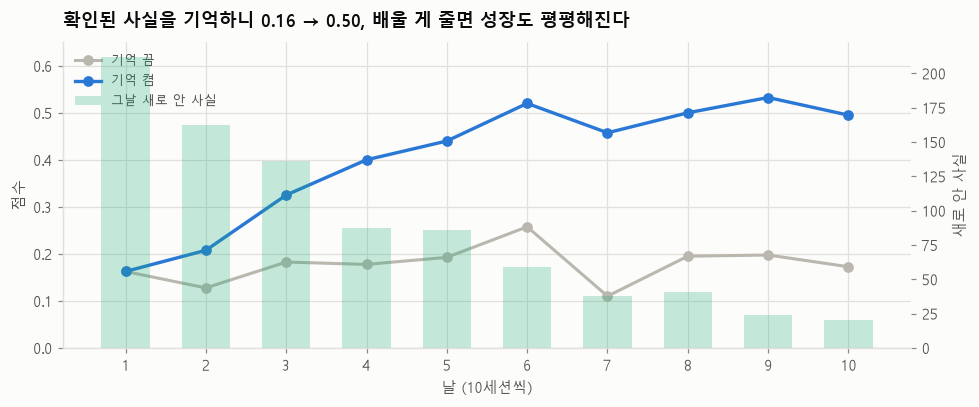

틀린 기억 비율: 0.0 | 마지막에 아는 사실: 865


In [2]:

v6 = r["v6_stream"]
days = np.arange(1, 11)
fig, ax1 = plt.subplots(figsize=(9, 3.8))
ax1.plot(days, v6["memory-off"]["by_day"], color=V.NEUTRAL, lw=2, marker="o", label="기억 끔")
ax1.plot(days, v6["memory-on"]["by_day"], color=V.BLUE, lw=2.2, marker="o", label="기억 켬")
ax1.set_xlabel("날 (10세션씩)"); ax1.set_ylabel("점수"); ax1.set_ylim(0, 0.65); ax1.set_xticks(days)
ax2 = ax1.twinx()
ax2.bar(days, v6["memory-on"]["facts_learned_per_day"], color=V.AQUA, alpha=0.25, width=0.6, label="그날 새로 안 사실")
ax2.set_ylabel("새로 안 사실", color=V.TEXT_SECONDARY); ax2.grid(False)
lines = ax1.get_legend_handles_labels(); bars = ax2.get_legend_handles_labels()
ax1.legend(lines[0] + bars[0], lines[1] + bars[1], fontsize=8.5, frameon=False, loc="upper left")
ax1.set_title("확인된 사실을 기억하니 0.16 → 0.50, 배울 게 줄면 성장도 평평해진다", pad=10)
fig.tight_layout(); plt.show()
print("틀린 기억 비율:", v6["memory-on"]["recalled_wrong_share"], "| 마지막에 아는 사실:", v6["memory-on"]["facts_known_at_end"])


## 2. 배운 것을 다른 종류의 문제에 쓴다

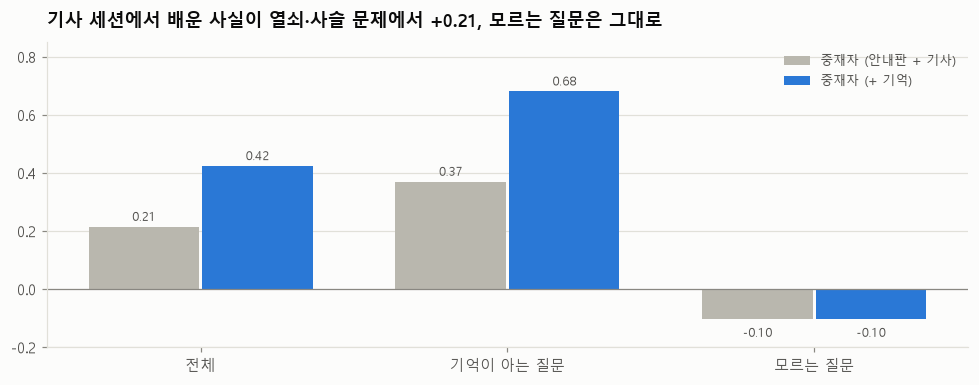

In [3]:

v11 = r["v11_cross_task"]
groups = [("전체", None), ("기억이 아는 질문", "known"), ("모르는 질문", "unknown")]
names = [("arbiter-2-channels", "중재자 (안내판 + 기사)", V.NEUTRAL), ("arbiter-3-channels (memory)", "중재자 (+ 기억)", V.BLUE)]
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(groups)); w = 0.36
for i, (k, label, color) in enumerate(names):
    vals = [v11[k] if g is None else v11[g][k] for _, g in groups]
    ax.bar(x + (i - 0.5) * (w + 0.01), vals, width=w, color=color, label=label)
    for xi, v in zip(x, vals):
        ax.text(xi + (i - 0.5) * (w + 0.01), v + (0.02 if v >= 0 else -0.06), f"{v:.2f}", ha="center", fontsize=8, color=V.TEXT_SECONDARY)
ax.axhline(0, color=V.MUTED, lw=0.8)
ax.set_xticks(x, [g for g, _ in groups]); ax.set_ylim(-0.2, 0.85); ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5, frameon=False, loc="upper right")
ax.set_title("기사 세션에서 배운 사실이 열쇠·사슬 문제에서 +0.21, 모르는 질문은 그대로", pad=10)
fig.tight_layout(); plt.show()



## 3. 정리

- **졸업 (기준 5개 모두 통과).** 기억 켬: 0.18 → 0.40(마지막 날들은 0.50 안팎). 틀린 기억은 0개.
- **옮겨 쓰기**: 중재자는 통로 2개로 학습했지만, 통로 이름 없이 같은 가중치를 쓰는 구조라 기억을 세 번째 통로로 학습 없이 받았다. +0.21.
- **한계**: 질문 글자가 같아야 찾는다(바꿔 말하면 못 찾음). 효과 크기는 세계가 얼마나 반복되는지에 달려 있다.
- **다음**: 뜻으로 찾는 기억, 그리고 전문가 붙이기.
